# The same controls reach better reservoirs for four tasks; comparison with re-fabrication

## Statement of the problem
Hold the fabricated device fixed and optimize the squeezing controls for four tasks. Compare the gain with what **re-fabricating** the device (different $g,\kappa,\epsilon$ at zero squeezing) would give, and read off the effective device parameters at each optimum.

**Tasks.** Ten-step Mackey–Glass; NARMA10 ($y_{t+1}=0.3y_t+0.05y_t\sum_{i=0}^9 y_{t-i}+1.5u_{t-9}u_t+0.1$); two-step Lorenz-63 ($x$ component, RK4, sampled every 0.05); nonlinear channel equalization (Jaeger & Haas 2004, 24 dB SNR, target $d_{n-2}$).

**Protocol per task.** Coarse $6\times6\times12$ scan; projected FD gradient descent from 4 random starts (100 evaluations); refabrication grid $g\in[0.25,0.9]$, $\kappa\in[0.1,0.6]$, $\epsilon\in[0.1,0.3]$ ($6\times6\times5$, extended to $\epsilon=0.5$ in `run_review.py refab`); effective parameters at the unsqueezed and optimized settings. The Lorenz task is drive-limited and is rerun with the opposite parametric phase ($\phi_s=\pi$, input amplified to $\epsilon e^{+r}$) in `run_lorenz_flip.py`.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


## Compute
`run_tasks.py` (~35 min), `run_lorenz_flip.py` (~5 min), `run_review.py refab` (~5 min).

In [2]:
if RUN:
    for cmd in (['python3', 'run_tasks.py'], ['python3', 'run_lorenz_flip.py'], ['python3', 'run_review.py', 'refab']): subprocess.run(cmd)
tk = ld('tasks.npz'); lf = ld('lorenz_flip.npz'); rv = ld('review.npz')
for n, name in (('mg', 'Mackey-Glass'), ('narma', 'NARMA10'), ('lorenz', 'Lorenz-63'), ('nce', 'channel equalization')):
    L0 = tk[f'{n}_L3'][0, 0, 0]; Lb = float(tk[f'{n}_bestL']); Lr = tk[f'{n}_refab'].min(); Lr2 = min(Lr, rv[f'refabx_{n}'].min()) if rv is not None and f'refabx_{n}' in rv else Lr
    print('%-22s squeezing %2.0f%% at (%.2f, %.2f, %.2f) | refab %2.0f%% (grid eps<=0.3), %2.0f%% (eps<=0.5) | recovered %s' % (name, 100 * (1 - Lb / L0), *tk[f'{n}_best'], 100 * (1 - Lr / L0), 100 * (1 - Lr2 / L0), '%.0f%%' % (100 * (L0 - Lb) / (L0 - Lr)) if L0 > Lr else 'n/a'))
if lf is not None: L0 = tk['lorenz_L3'][0, 0, 0]; print('Lorenz, amplifying phase: %.0f%% at (%.2f, %.2f, %.2f)' % (100 * (1 - lf['L3'].min() / L0), *lf['best']))

Mackey-Glass           squeezing 35% at (0.01, 0.21, -1.05) | refab 58% (grid eps<=0.3), 58% (eps<=0.5) | recovered 60%
NARMA10                squeezing 21% at (0.22, 0.49, -0.13) | refab 21% (grid eps<=0.3), 23% (eps<=0.5) | recovered 102%
Lorenz-63              squeezing  9% at (0.00, 0.40, 0.09) | refab 85% (grid eps<=0.3), 94% (eps<=0.5) | recovered 11%
channel equalization   squeezing 94% at (0.50, 0.50, -1.57) | refab 79% (grid eps<=0.3), 80% (eps<=0.5) | recovered 119%
Lorenz, amplifying phase: 78% at (0.50, 0.50, 2.62)


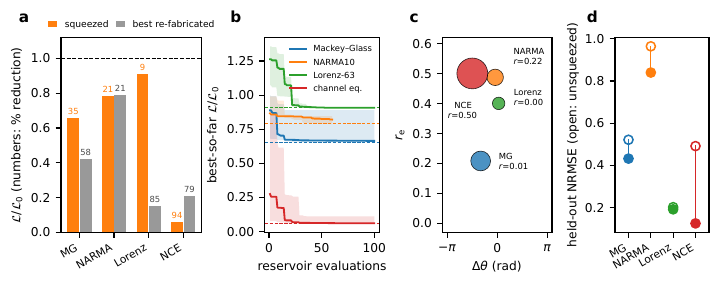

```latex
\begin{tabular}{lccccc}
\toprule
Parameter & unsqueezed & Mackey–Glass & NARMA10 & Lorenz-63 & channel eq.\\
\midrule
$(r,\re,\dth)$ & $(0,0,0)$ & $(0.01,0.21,-1.05)$ & $(0.22,0.49,-0.13)$ & $(0.00,0.40,0.09)$ & $(0.50,0.50,-1.57)$\\
$\epsilon_{\rm eff}$ & 0.200 & 0.197 & 0.160 & 0.200 & 0.121\\
$\Omega_a$ & 1.000 & 1.000 & 0.909 & 1.000 & 0.648\\
$g\cosh r$ & 0.500 & 0.500 & 0.512 & 0.500 & 0.564\\
$g\sinh r$ & 0.000 & 0.007 & 0.112 & 0.000 & 0.261\\
$\gamma_x^{\rm eff}$ & 0.187 & 0.216 & 0.468 & 0.280 & 0.355\\
$\gamma_y^{\rm eff}$ & 0.187 & 0.214 & 0.473 & 0.276 & 0.626\\
$\gamma_z^{\rm eff}$ & 0.279 & 0.296 & 0.481 & 0.338 & 0.470\\
$\mathrm{Var}(Q)$ & 1.000 & 1.142 & 3.377 & 1.225 & 9.127\\
$\mathrm{Var}(P)$ & 1.000 & 0.994 & 1.293 & 1.266 & 0.808\\
$\langle a^\dagger a\rangle_{\rm ss}$ & 0.000 & 0.034 & 0.669 & 0.123 & 1.990\\
$\langle\sigma^\dagger\sigma\rangle_{\rm ss}$ & 0.000 & 0.030 & 0.236 & 0.092 & 0.259\\
Liouvillian gap & 0.075 & 0.087 & 0.183 & 0.115 & 0.174\\
\bottomrule
\end{tabular}
```

In [3]:
make_figs.fig3_tasks(); make_figs.efftable(); show('paper/figs/fig3_tasks.pdf'); display(Markdown('```latex\n' + open('paper/efftable.tex').read() + '\n```'))

**Figure 3.** (a) Loss relative to unsqueezed: squeezed optimum vs best re-fabricated device. (b) Gradient-descent curves. (c) Optimal controls per task. (d) Held-out NRMSE. The effective-parameter table states each optimum in fabrication terms. Lorenz needs the amplifying branch; the laser (notebook 06) needs the de-amplifying one; the parametric phase is a binary fourth control.